In [1]:
import xarray as xr
import geopandas as gpd
import numpy as np
import pandas as pd
import glob
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import random

import sys
sys.path.insert(0, '/glade/u/home/dcalhoun/censuswxindex')
from censuswxindex import aggregate as wxagg

In [2]:
# Shapefile for aggregation
scratch = '/glade/derecho/scratch/dcalhoun'
shapefile_path = scratch + '/census/shapefiles/nhgis0001_shapefile_tl2023_us_county_2023/US_county_2023.shp'

In [3]:
def build_fc_files(scratch, start, end, freq, lead_times):
    """Build list of forecast files (path, init_time, lead_time) for the given date range."""
    dates = pd.date_range(start=start, end=end, freq=freq)
    fc_files = []
    for init_time in dates:
        for lead_time in lead_times:
            date_str = init_time.strftime("%Y%m%d%H%M")
            year = date_str[:4]
            month = date_str[4:6]
            day = date_str[6:8]
            hour = date_str[8:]
            fc_path = glob.glob(scratch + f'/ecmwf/ifs/fc/0.125/2t/{hour}/{lead_time}/{year}/{month}/*{day}.nc')
            if fc_path:
                fc_files.append((fc_path[0], str(init_time), lead_time))
    return fc_files

In [4]:
def build_an_files(scratch, start, end, freq):
    """Build list of analysis files (path, date) for the given date range."""
    dates = pd.date_range(start=start, end=end, freq=freq)
    an_files = []
    for date in dates:
        date_str = date.strftime("%Y%m%d")
        year = date_str[:4]
        month = date_str[4:6]
        an_path = glob.glob(scratch + f'/ecmwf/ifs/an/0.125/2t/{year}/{month}/*{date_str}.nc')
        if an_path:
            an_files.append((an_path[0], str(date)))
    return an_files

In [5]:
# Build our lists of forecast and analysis files
start, end, freq = '2020-01-01', '2024-01-01', '12h'
lead_times = [12, 24, 36]
fc_files = build_fc_files(scratch, start=start, end=end, freq=freq, lead_times=lead_times)
an_files = build_an_files(scratch, start=start, end=end, freq=freq)
n_files = len(fc_files)
print(f'fc_files: {n_files}, an_files: {len(an_files)}')

fc_files: 5846, an_files: 2923


In [6]:
# Pick random valid times and select aligned forecast + analysis
valid_from_fc = {pd.to_datetime(init) + pd.Timedelta(hours=lead): (path, init, lead) for path, init, lead in fc_files}
valid_from_an = {pd.to_datetime(t): (path, t) for path, t in an_files}
common_valid = sorted(set(valid_from_fc) & set(valid_from_an))
print("n_common: ", len(common_valid))
n_pick = min(4, len(common_valid))
picked_valid = sorted(random.sample(common_valid, n_pick))
fc_selected = [valid_from_fc[vt] for vt in picked_valid]
an_selected = [valid_from_an[vt] for vt in picked_valid]
for vt in picked_valid:
    fc_file = valid_from_fc[vt][0]
    an_file = valid_from_an[vt][0]
    fc_end = fc_file.split('/')[-1]
    an_end = an_file.split('/')[-1]
    print(f'{vt}: fc={fc_end} an={an_end}')

n_common:  2922
2021-01-01 00:00:00: fc=ifs_fc_2t_1200_12_20201231.nc an=ifs_an_2t_20210101.nc
2021-02-24 00:00:00: fc=ifs_fc_2t_1200_12_20210223.nc an=ifs_an_2t_20210224.nc
2023-01-26 00:00:00: fc=ifs_fc_2t_1200_12_20230125.nc an=ifs_an_2t_20230126.nc
2023-12-25 12:00:00: fc=ifs_fc_2t_0000_12_20231225.nc an=ifs_an_2t_20231225.nc


In [7]:
# Define our GeoAggregator with our shapefile and grid
# Calculates a weightmap of overlaps between grid boxes and polygons
geo_agg = wxagg.GeoAggregator(shapefile_path=shapefile_path, grid_path=fc_selected[0][0])

In [8]:
geo_agg

GeoAggregator
shapefile: '/glade/derecho/scratch/dcalhoun/census/shapefiles/nhgis0001_shapefile_tl2023_us_county_2023/US_county_2023.shp'
Coordinates:
  * latitude   (latitude) float32 804B 49.5 49.38 49.25 ... 24.75 24.62 24.5
  * longitude  (longitude) float32 2kB -125.0 -124.9 -124.8 ... -66.62 -66.5
CRS: 'WGS84'

In [9]:
# Build our ForecastAggregator and AnalysisAggregator
# from our forecast and analysis files
# We use the weightmap we already calculated
fc_agg = wxagg.ForecastAggregator.from_GeoAggregator(geo_agg, forecast_files=fc_selected, var_name="t2m")
an_agg = wxagg.AnalysisAggregator.from_GeoAggregator(geo_agg, analysis_files=an_selected, var_name="t2m")

In [10]:
fc_agg

ForecastAggregator
n_files: 4
init_times:
	2020-12-31 12:00:00
	2021-02-23 12:00:00
	2023-01-25 12:00:00
	2023-12-25 00:00:00
lead_times: [12]
var_name: 't2m'
shapefile: '/glade/derecho/scratch/dcalhoun/census/shapefiles/nhgis0001_shapefile_tl2023_us_county_2023/US_county_2023.shp'
Coordinates:
  * latitude   (latitude) float32 804B 49.5 49.38 49.25 ... 24.75 24.62 24.5
  * longitude  (longitude) float32 2kB -125.0 -124.9 -124.8 ... -66.62 -66.5
CRS: 'WGS84'

In [11]:
an_agg

AnalysisAggregator
n_files: 4
times:
	2021-01-01 00:00:00
	2021-02-24 00:00:00
	2023-01-26 00:00:00
	2023-12-25 12:00:00
var_name: 't2m'
shapefile: '/glade/derecho/scratch/dcalhoun/census/shapefiles/nhgis0001_shapefile_tl2023_us_county_2023/US_county_2023.shp'
Coordinates:
  * latitude   (latitude) float32 804B 49.5 49.38 49.25 ... 24.75 24.62 24.5
  * longitude  (longitude) float32 2kB -125.0 -124.9 -124.8 ... -66.62 -66.5
CRS: 'WGS84'

In [12]:
# Run the aggregation to build a data table of our forecast data
df_fc = fc_agg.build_data_table()

In [13]:
# Same for analysis
df_an = an_agg.build_data_table()

In [14]:
df_fc

,geo_id,valid_time,init_time,lead_time,t2m
0,01001,2021-01-01 00:00:00,2020-12-31 12:00:00,12,290.276439
1,01003,2021-01-01 00:00:00,2020-12-31 12:00:00,12,293.127369
2,01005,2021-01-01 00:00:00,2020-12-31 12:00:00,12,291.085310
3,01007,2021-01-01 00:00:00,2020-12-31 12:00:00,12,289.303598
4,01009,2021-01-01 00:00:00,2020-12-31 12:00:00,12,286.973499
...,...,...,...,...,...
12431,56037,2023-12-25 12:00:00,2023-12-25 00:00:00,12,256.575865
12432,56039,2023-12-25 12:00:00,2023-12-25 00:00:00,12,252.053267
12433,56041,2023-12-25 12:00:00,2023-12-25 00:00:00,12,258.368333
12434,56043,2023-12-25 12:00:00,2023-12-25 00:00:00,12,259.609869


In [15]:
df_an

,geo_id,time,t2m
0,01001,2021-01-01 00:00:00,291.159213
1,01003,2021-01-01 00:00:00,294.408342
2,01005,2021-01-01 00:00:00,292.035432
3,01007,2021-01-01 00:00:00,290.107654
4,01009,2021-01-01 00:00:00,287.495331
...,...,...,...
12431,56037,2023-12-25 12:00:00,256.307304
12432,56039,2023-12-25 12:00:00,252.229158
12433,56041,2023-12-25 12:00:00,258.157705
12434,56043,2023-12-25 12:00:00,258.401881


In [16]:
# Save our aggregated features
fc_agg.save_data_table("test_fc.csv")
an_agg.save_data_table("test_an.csv")

In [17]:
# Create table with bias (forecast - analysis) and abs_error
var = 't2m'
df_error = pd.merge(
    df_fc, df_an,
    left_on=['geo_id', 'valid_time'], right_on=['geo_id', 'time'],
    suffixes=('_fc', '_an'), how='inner'
)
df_error['bias'] = df_error[f'{var}_fc'] - df_error[f'{var}_an']
df_error['abs_error'] = df_error['bias'].abs()
df_error = df_error[['geo_id', 'valid_time', 'init_time', 'lead_time', f'{var}_fc', f'{var}_an', 'bias', 'abs_error']]
df_error

,geo_id,valid_time,init_time,lead_time,t2m_fc,t2m_an,bias,abs_error
0,01001,2021-01-01 00:00:00,2020-12-31 12:00:00,12,290.276439,291.159213,-0.882774,0.882774
1,01003,2021-01-01 00:00:00,2020-12-31 12:00:00,12,293.127369,294.408342,-1.280972,1.280972
2,01005,2021-01-01 00:00:00,2020-12-31 12:00:00,12,291.085310,292.035432,-0.950122,0.950122
3,01007,2021-01-01 00:00:00,2020-12-31 12:00:00,12,289.303598,290.107654,-0.804056,0.804056
4,01009,2021-01-01 00:00:00,2020-12-31 12:00:00,12,286.973499,287.495331,-0.521832,0.521832
...,...,...,...,...,...,...,...,...
12431,56037,2023-12-25 12:00:00,2023-12-25 00:00:00,12,256.575865,256.307304,0.268561,0.268561
12432,56039,2023-12-25 12:00:00,2023-12-25 00:00:00,12,252.053267,252.229158,-0.175891,0.175891
12433,56041,2023-12-25 12:00:00,2023-12-25 00:00:00,12,258.368333,258.157705,0.210628,0.210628
12434,56043,2023-12-25 12:00:00,2023-12-25 00:00:00,12,259.609869,258.401881,1.207987,1.207987


In [18]:
# Statistics by valid time
df_error.groupby('valid_time').bias.describe()

,count,mean,std,min,25%,50%,75%,max
valid_time,,,,,,,,
2021-01-01 00:00:00,3109.0,-0.662521,1.181340,-5.757435,-1.497656,-0.786387,0.241368,4.281714
2021-02-24 00:00:00,3109.0,-2.833776,1.486654,-6.631472,-4.027835,-2.881752,-1.723854,1.545471
2023-01-26 00:00:00,3109.0,-0.101488,1.062290,-3.906622,-0.651716,0.020404,0.568870,6.705687
2023-12-25 12:00:00,3109.0,-0.281801,1.046946,-2.892273,-1.084406,-0.413086,0.502621,3.772855


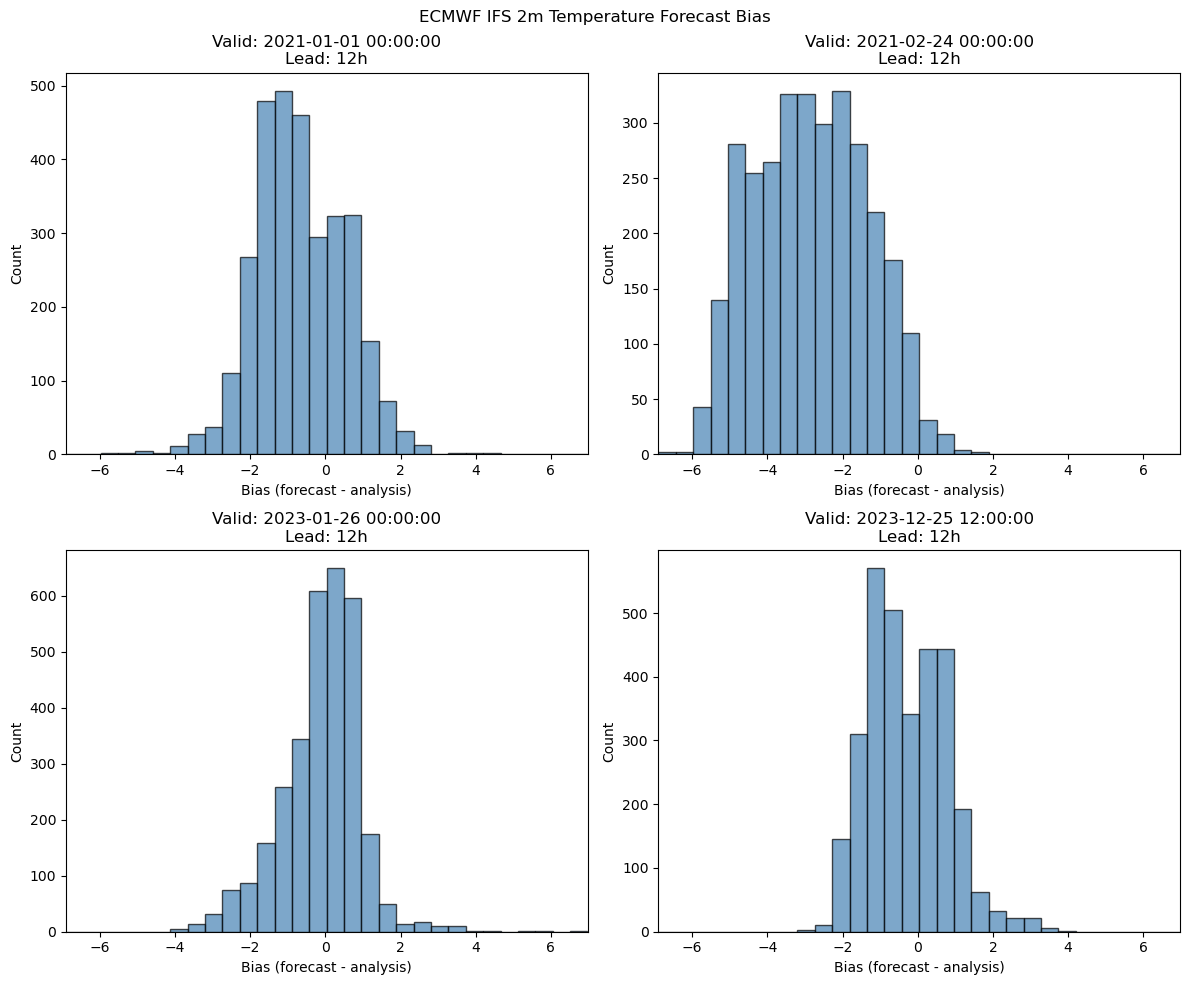

In [19]:
# Plot forecast bias histograms by valid time
valid_times = sorted(df_error['valid_time'].unique())
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
bins = 30

bias_min = df_error['bias'].min()
bias_max = df_error['bias'].max()
padding = 0.02 * (bias_max - bias_min) if bias_max != bias_min else 0.1
bmin_pad = bias_min - padding
bmax_pad = bias_max + padding

bin_edges = np.linspace(bmin_pad, bmax_pad, bins + 1)

for ax, vt in zip(axes, valid_times):
    sub = df_error[df_error['valid_time'] == vt]
    ax.hist(sub['bias'], bins=bin_edges, color='steelblue', edgecolor='k', alpha=0.7)
    ax.set_title(f'Valid: {vt}\nLead: {sub["lead_time"].iloc[0]}h')
    ax.set_xlabel('Bias (forecast - analysis)')
    ax.set_ylabel('Count')
    ax.set_xlim([bmin_pad, bmax_pad])

plt.suptitle('ECMWF IFS 2m Temperature Forecast Bias')
plt.tight_layout()
plt.show()

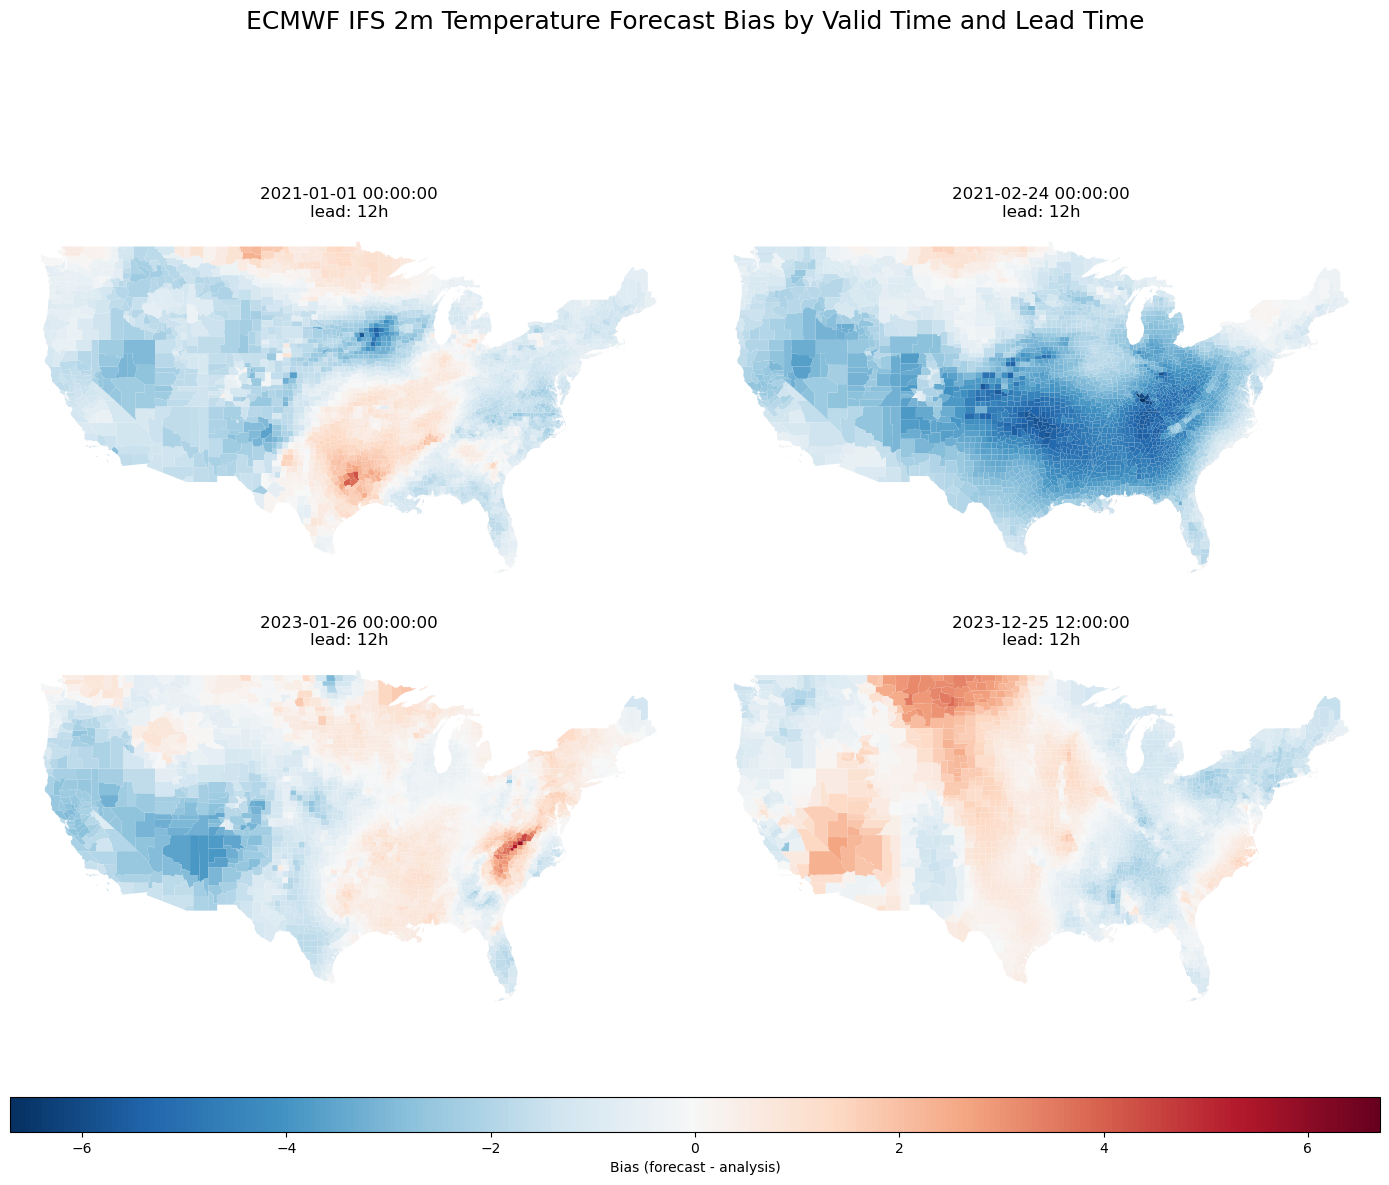

In [20]:
# Plot bias maps by valid time
fc_agg.shapefile.rename(columns={'GEOID': 'geo_id'}, inplace=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes = axes.flatten()

bias_max = np.abs(df_error['bias']).max()
vmin, vmax = -bias_max, bias_max
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = 'RdBu_r'

valid_times = sorted(df_error['valid_time'].unique())
for ax, valid_time in zip(axes, valid_times):
    sub = df_error[df_error['valid_time'] == valid_time]
    gdf_plot = fc_agg.shapefile.merge(sub[['geo_id', 'bias']], on='geo_id', how='inner')
    gdf_plot.plot(ax=ax, column='bias', cmap=cmap, norm=norm)
    lead_val = sub['lead_time'].iloc[0]
    ax.set_title(f'{valid_time}\nlead: {lead_val}h')
    ax.set_axis_off()

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

fig.suptitle(
    'ECMWF IFS 2m Temperature Forecast Bias by Valid Time and Lead Time', 
    fontsize=18, 
    y=0.90  # Move title closer to panels
)
plt.tight_layout(rect=[0, 0.08, 1, 0.94])  # Adjust for space at bottom for colorbar and a bit at top for title

fig.colorbar(
    sm,
    ax=axes.tolist(),
    orientation='horizontal',
    fraction=0.04,
    pad=0.07,
    aspect=40,
    label='Bias (forecast - analysis)'
)
plt.show()

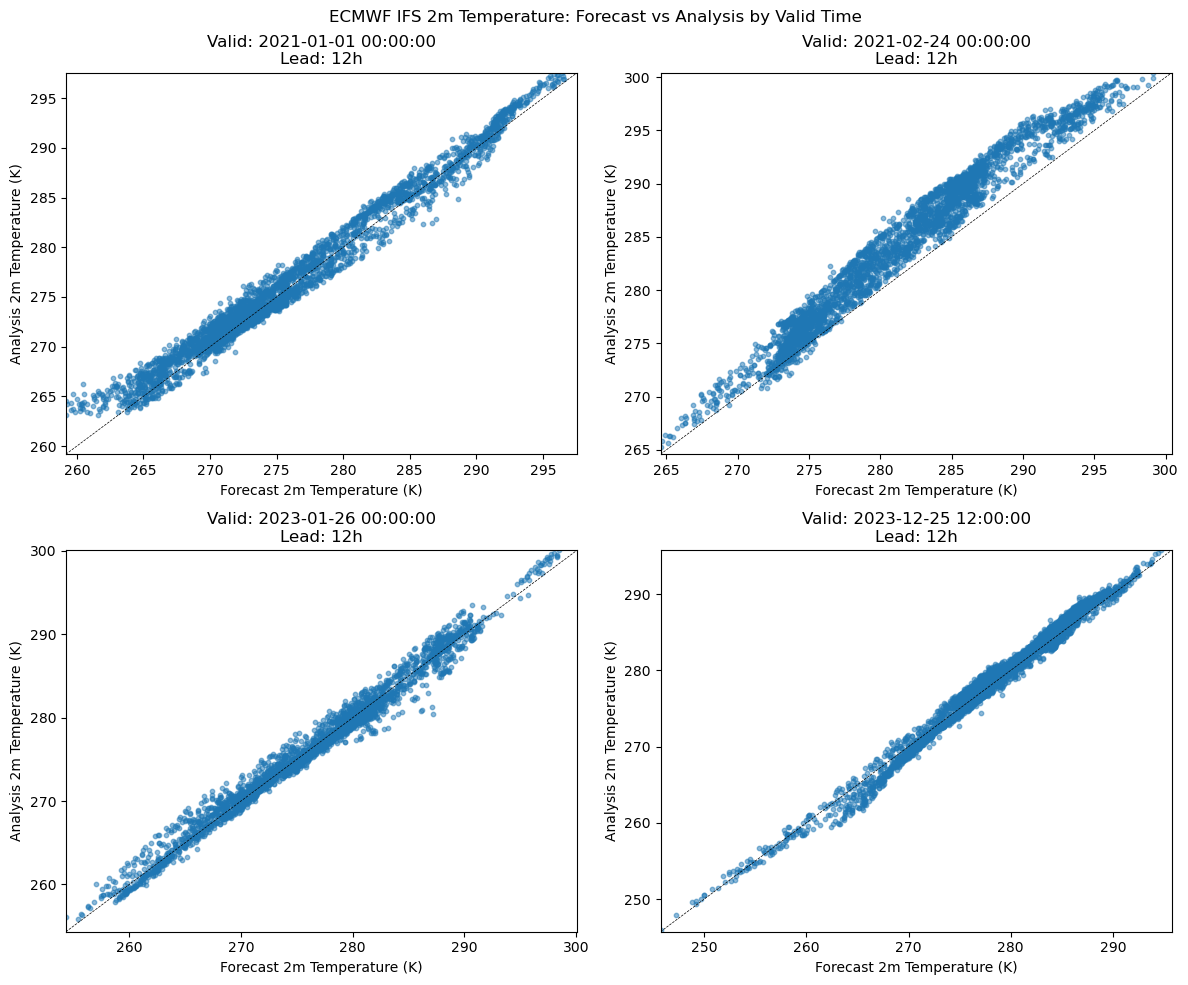

In [21]:
# Scatter plot: forecast vs analysis temperature by valid time
valid_times = sorted(df_error['valid_time'].unique())
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, vt in zip(axes, valid_times):
    sub = df_error[df_error['valid_time'] == vt]
    ax.scatter(sub['t2m_fc'], sub['t2m_an'], alpha=0.5, s=10)
    lims = [sub[['t2m_fc', 't2m_an']].min().min(), sub[['t2m_fc', 't2m_an']].max().max()]
    ax.plot(lims, lims, 'k--', linewidth=0.5, label='1:1')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel('Forecast 2m Temperature (K)')
    ax.set_ylabel('Analysis 2m Temperature (K)')
    ax.set_title(f'Valid: {vt}\nLead: {sub["lead_time"].iloc[0]}h')

plt.suptitle('ECMWF IFS 2m Temperature: Forecast vs Analysis by Valid Time')
plt.tight_layout()
plt.show()